#  Sentiment Analysis on IMDB Movie Reviews
## Natural Language Processing (NLP) Project

---

##  Project Overview

Sentiment analysis is one of the most widely applied NLP tasks in the industry.  
Companies use it to analyze customer reviews, social media posts, support tickets, and more.

In this project, we build a **text classification model** that automatically classifies IMDB movie reviews as **Positive** or **Negative** using Natural Language Processing techniques.

The dataset contains **50,000 movie reviews** from IMDB, equally split between positive and negative sentiments.

---

##  Objectives

- Perform **text cleaning** and preprocessing
- Apply **NLP techniques**: tokenization, stopword removal, stemming
- Convert text into numerical features using **TF-IDF Vectorization**
- Train and compare **multiple ML classifiers**
- Evaluate models using accuracy, precision, recall, and F1-score
- Visualize insights with **word clouds** and feature analysis

---

##  Dataset Description

| Column | Description |
|---|---|
| review | The full text of the movie review |
| sentiment | Target label: `positive` or `negative` |

- **Total samples**: 50,000
- **Positive reviews**: 25,000
- **Negative reviews**: 25,000

---

##  Tools & Libraries

- **Python** — core language
- **Pandas & NumPy** — data handling
- **NLTK** — text preprocessing
- **Scikit-learn** — vectorization, models, evaluation
- **Matplotlib & Seaborn** — visualization
- **WordCloud** — text visualization

---

##  Step 1 — Install & Import Libraries

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Sklearn — vectorization
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Sklearn — evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import LabelEncoder

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(' All libraries imported successfully!')

 All libraries imported successfully!


##  Step 2 — Load Dataset

In [2]:
df = pd.read_csv('IMDB Dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (50000, 2)
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


##  Step 3 — Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [4]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

print()
print('Sentiment distribution:')
print(df['sentiment'].value_counts())

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
# Sample reviews
print('=== POSITIVE REVIEW SAMPLE ===')
print(df[df['sentiment']=='positive']['review'].iloc[0][:500])
print()
print('=== NEGATIVE REVIEW SAMPLE ===')
print(df[df['sentiment']=='negative']['review'].iloc[0][:500])

=== POSITIVE REVIEW SAMPLE ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

=== NEGATIVE REVIEW SAMPLE ===
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real 

##  Step 4 — Exploratory Data Analysis (EDA)

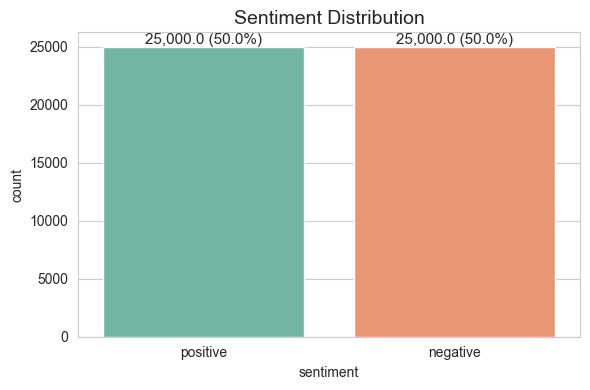

In [6]:
# Sentiment class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Sentiment Distribution', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

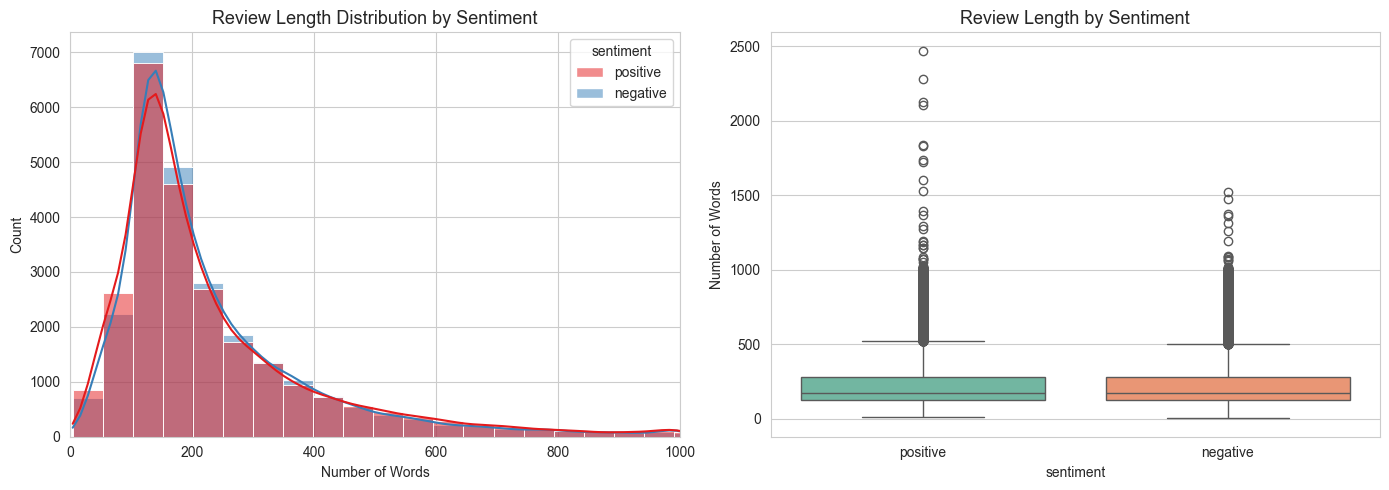

Average review length by sentiment:
             count       mean         std   min    25%    50%    75%     max
sentiment                                                                   
negative   25000.0  229.46456  164.947795   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.84932  177.497046  10.0  125.0  172.0  284.0  2470.0


In [7]:
# Review length analysis
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='review_length', hue='sentiment',
             bins=50, kde=True, palette='Set1', ax=axes[0])
axes[0].set_title('Review Length Distribution by Sentiment', fontsize=13)
axes[0].set_xlabel('Number of Words')
axes[0].set_xlim(0, 1000)

sns.boxplot(data=df, x='sentiment', y='review_length',
            palette='Set2', ax=axes[1])
axes[1].set_title('Review Length by Sentiment', fontsize=13)
axes[1].set_ylabel('Number of Words')

plt.tight_layout()
plt.show()

print('Average review length by sentiment:')
print(df.groupby('sentiment')['review_length'].describe())

##  Step 5 — Text Cleaning & Preprocessing

Raw text needs to be cleaned before modeling. We apply the following steps:
1. Remove HTML tags
2. Remove special characters and punctuation
3. Convert to lowercase
4. Remove stopwords
5. Apply stemming

In [8]:
stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def clean_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # 3. Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # 4. Lowercase
    text = text.lower()
    # 5. Tokenize
    tokens = text.split()
    # 6. Remove stopwords and stem
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print('Cleaning text... This may take a moment...')
df['clean_review'] = df['review'].apply(clean_text)
print(' Text cleaning complete!')

print()
print('Original review:')
print(df['review'].iloc[0][:200])
print()
print('Cleaned review:')
print(df['clean_review'].iloc[0][:200])

Cleaning text... This may take a moment...
 Text cleaning complete!

Original review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

Cleaned review:
one review mention watch episod hook right exactli happen first thing struck brutal unflinch scene violenc set right word trust show faint heart timid show pull punch regard drug sex violenc hardcor c


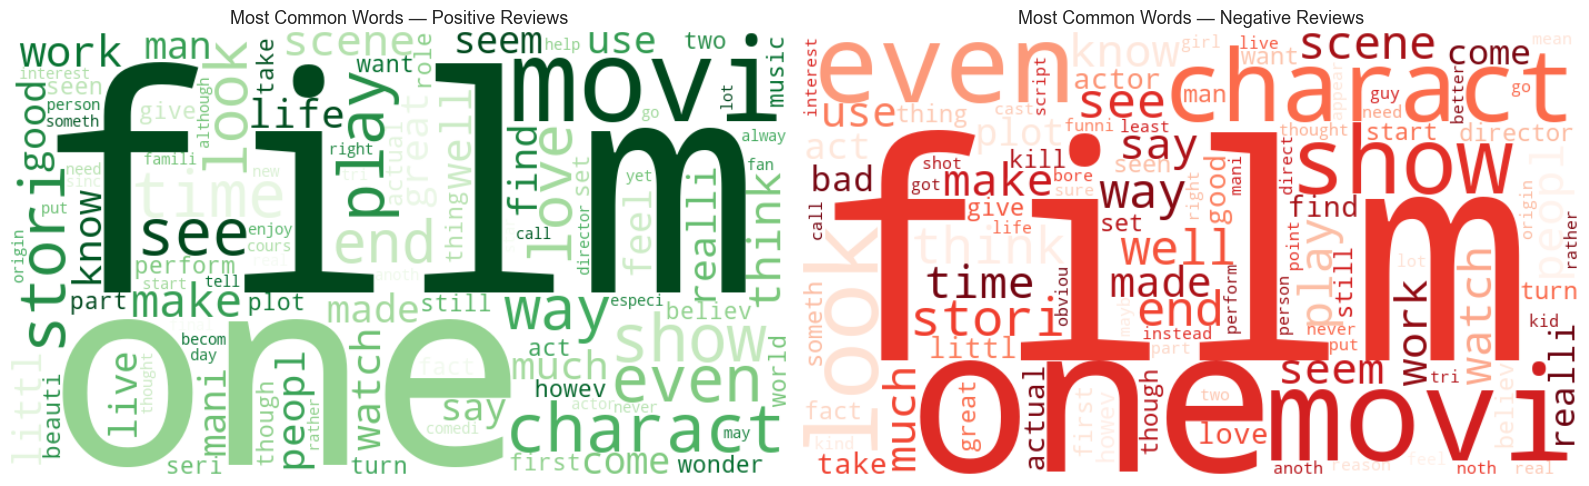

In [9]:
# Word Clouds
positive_text = ' '.join(df[df['sentiment']=='positive']['clean_review'])
negative_text = ' '.join(df[df['sentiment']=='negative']['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=700, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Common Words — Positive Reviews', fontsize=13)

wc_neg = WordCloud(width=700, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Common Words — Negative Reviews', fontsize=13)

plt.tight_layout()
plt.show()

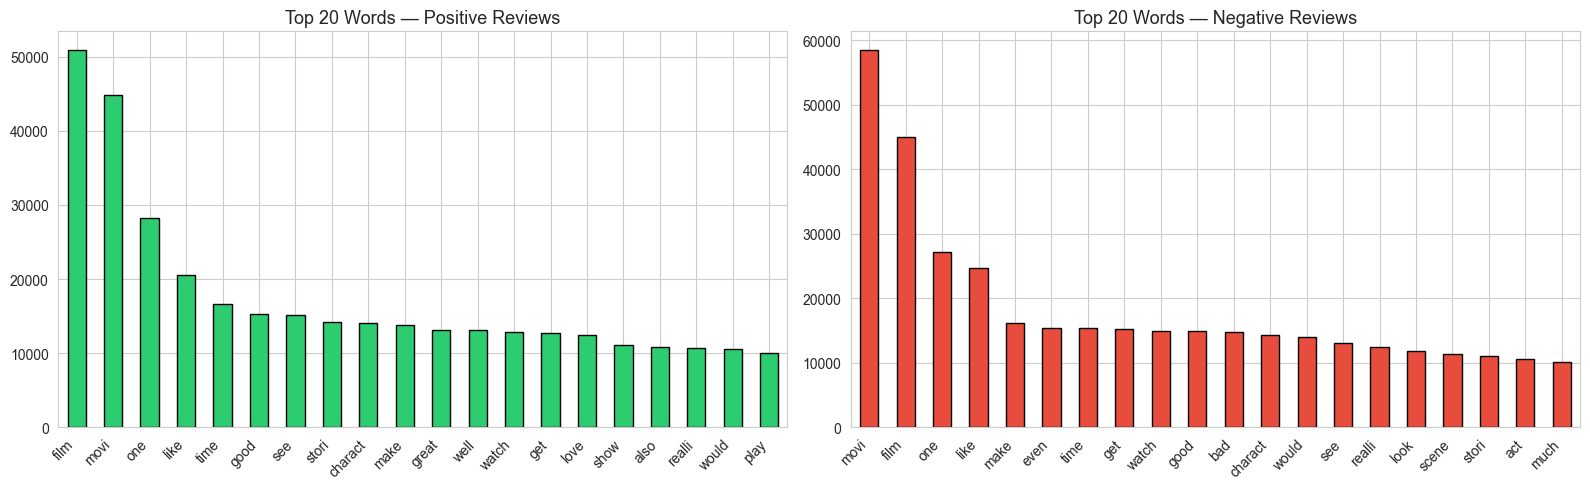

In [10]:
# Top words per class
def get_top_words(texts, n=20):
    cv = CountVectorizer(max_features=n)
    cv.fit(texts)
    return pd.Series(
        cv.transform(texts).toarray().sum(axis=0),
        index=cv.get_feature_names_out()
    ).sort_values(ascending=False)

top_pos = get_top_words(df[df['sentiment']=='positive']['clean_review'])
top_neg = get_top_words(df[df['sentiment']=='negative']['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_pos.plot(kind='bar', color='#2ecc71', edgecolor='black', ax=axes[0])
axes[0].set_title('Top 20 Words — Positive Reviews', fontsize=13)
axes[0].set_xticklabels(top_pos.index, rotation=45, ha='right')

top_neg.plot(kind='bar', color='#e74c3c', edgecolor='black', ax=axes[1])
axes[1].set_title('Top 20 Words — Negative Reviews', fontsize=13)
axes[1].set_xticklabels(top_neg.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

##  Step 6 — Feature Extraction (TF-IDF Vectorization)

**TF-IDF (Term Frequency — Inverse Document Frequency)** converts text into numerical features by measuring how important a word is in a document relative to the entire corpus.

In [11]:
# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])   # positive=1, negative=0

print('Label encoding:')
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Train / test split
X_text = df['clean_review']
y      = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples : {len(X_train_text)}')
print(f'Test samples     : {len(X_test_text)}')

Label encoding:
{'negative': np.int64(0), 'positive': np.int64(1)}

Training samples : 40000
Test samples     : 10000


In [12]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),      # unigrams + bigrams
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print(f'TF-IDF Feature Matrix shape (train): {X_train.shape}')
print(f'TF-IDF Feature Matrix shape (test) : {X_test.shape}')

TF-IDF Feature Matrix shape (train): (40000, 50000)
TF-IDF Feature Matrix shape (test) : (10000, 50000)


##  Step 7 — Model Building & Training

In [13]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Naive Bayes'          : MultinomialNB(alpha=0.1),
    'Linear SVM'           : LinearSVC(C=1.0, max_iter=2000, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc  = accuracy_score(y_test, pred)
    results[name] = {'Accuracy': round(acc * 100, 2)}
    print(f'{name:<25} | Accuracy: {acc*100:.2f}%')

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print()
print(results_df)

Logistic Regression       | Accuracy: 90.11%
Naive Bayes               | Accuracy: 88.11%
Linear SVM                | Accuracy: 90.47%

                     Accuracy
Linear SVM              90.47
Logistic Regression     90.11
Naive Bayes             88.11


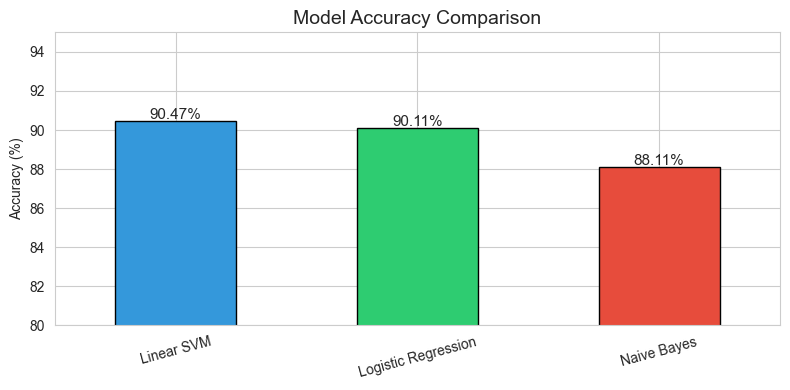

In [14]:
# Plot model comparison
plt.figure(figsize=(8, 4))
results_df['Accuracy'].plot(kind='bar', color=['#3498db','#2ecc71','#e74c3c'],
                             edgecolor='black')
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=15)
plt.ylim(80, 95)
for i, v in enumerate(results_df['Accuracy']):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

##  Step 8 — Best Model Evaluation

In [15]:
# Logistic Regression as best model
best_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print('Classification Report — Logistic Regression')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



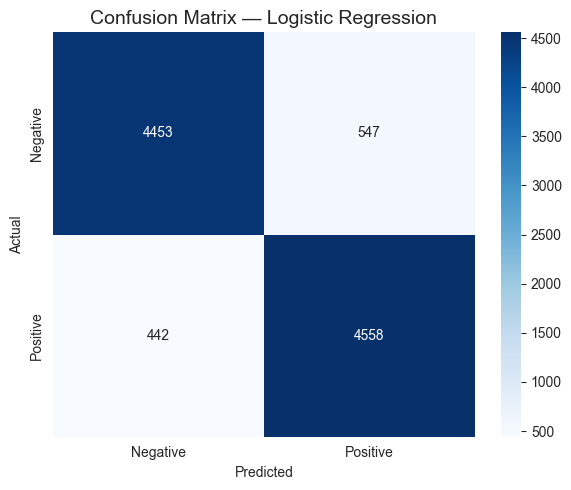

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Confusion Matrix — Logistic Regression', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

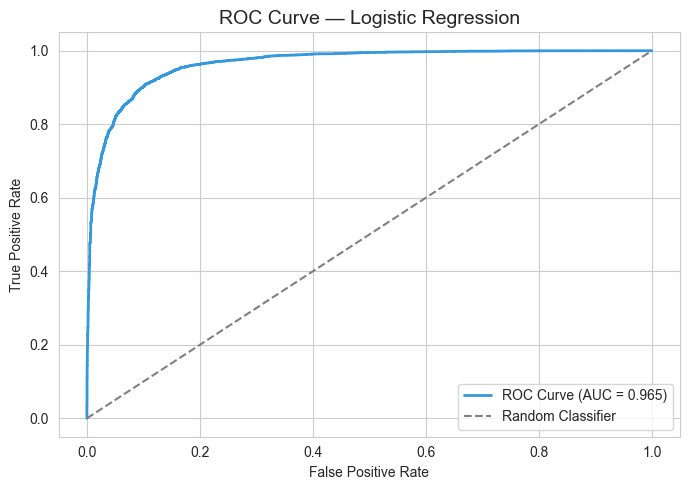

In [17]:
# ROC Curve
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

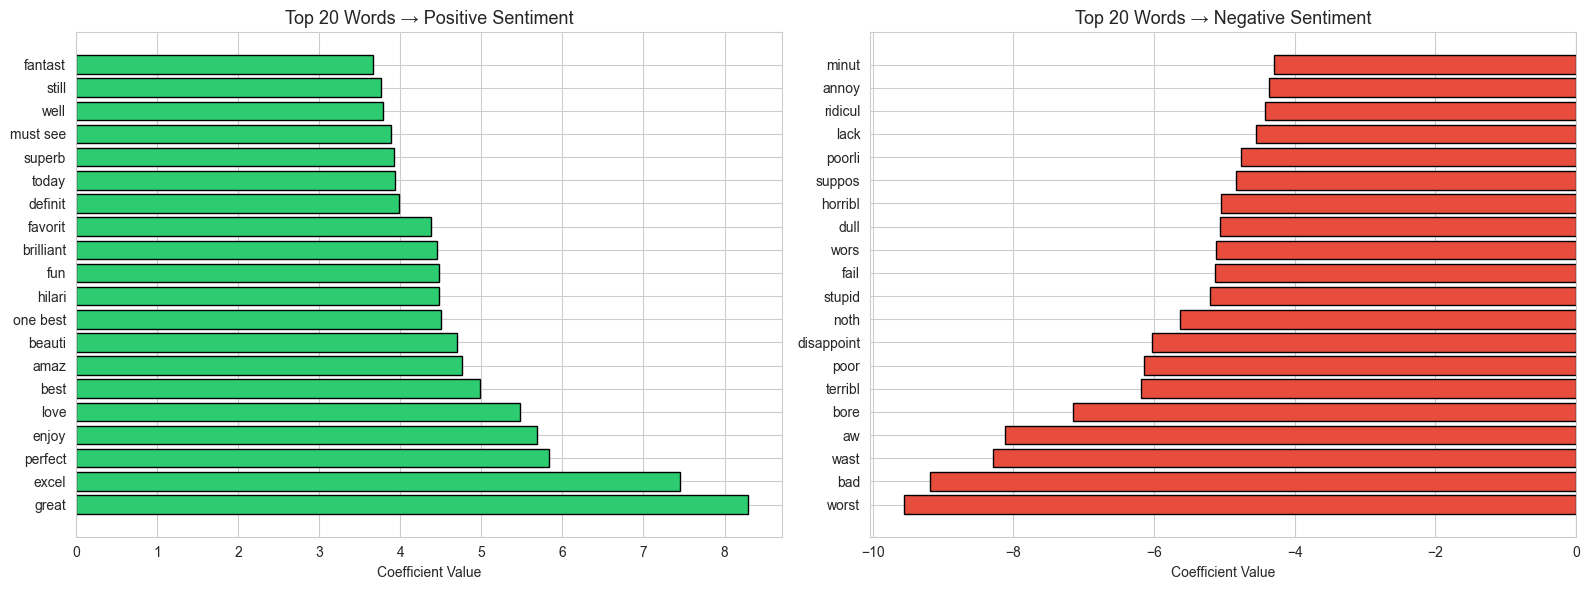

In [18]:
# Most informative features (top words for each class)
feature_names = np.array(tfidf.get_feature_names_out())
coef = best_model.coef_[0]

top_positive_idx = np.argsort(coef)[-20:][::-1]
top_negative_idx = np.argsort(coef)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(range(20), coef[top_positive_idx], color='#2ecc71', edgecolor='black')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(feature_names[top_positive_idx])
axes[0].set_title('Top 20 Words → Positive Sentiment', fontsize=13)
axes[0].set_xlabel('Coefficient Value')

axes[1].barh(range(20), coef[top_negative_idx], color='#e74c3c', edgecolor='black')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(feature_names[top_negative_idx])
axes[1].set_title('Top 20 Words → Negative Sentiment', fontsize=13)
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

##  Step 9 — Real-Time Prediction Function

In [19]:
def predict_sentiment(review_text):
    """
    Predicts the sentiment of a given movie review.
    
    Parameters:
        review_text (str): The movie review text
    
    Returns:
        dict: sentiment label and confidence score
    """
    # Clean
    cleaned = clean_text(review_text)
    # Vectorize
    vec = tfidf.transform([cleaned])
    # Predict
    pred  = best_model.predict(vec)[0]
    proba = best_model.predict_proba(vec)[0]
    
    label      = 'POSITIVE ' if pred == 1 else 'NEGATIVE '
    confidence = proba[pred] * 100
    
    return {'Sentiment': label, 'Confidence': f'{confidence:.2f}%'}


# Test with sample reviews
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat the whole time.",
    "Terrible movie. Boring plot, bad acting, total waste of time. I want my money back.",
    "It was okay, nothing special. Some parts were good but overall pretty average."
]

print('=== Real-Time Sentiment Prediction ===')
print()
for i, review in enumerate(test_reviews, 1):
    result = predict_sentiment(review)
    print(f'Review {i}: "{review[:80]}..."')
    print(f'  → Sentiment : {result["Sentiment"]}')
    print(f'  → Confidence: {result["Confidence"]}')
    print()

=== Real-Time Sentiment Prediction ===

Review 1: "This movie was absolutely fantastic! The acting was superb and the story kept me..."
  → Sentiment : POSITIVE 
  → Confidence: 92.88%

Review 2: "Terrible movie. Boring plot, bad acting, total waste of time. I want my money ba..."
  → Sentiment : NEGATIVE 
  → Confidence: 99.93%

Review 3: "It was okay, nothing special. Some parts were good but overall pretty average...."
  → Sentiment : NEGATIVE 
  → Confidence: 76.69%



---

##  Step 10 — Conclusion & Key Insights

###  Summary

In this project, we built a complete NLP pipeline to classify IMDB movie reviews as positive or negative.

###  Key Findings

| Finding | Detail |
|---|---|
| **Dataset balance** | Perfectly balanced — 25K positive, 25K negative |
| **Review length** | Positive reviews are slightly longer on average |
| **Strong positive words** | excellent, brilliant, wonderful, outstanding |
| **Strong negative words** | worst, awful, terrible, boring, waste |
| **Best model** | Logistic Regression with TF-IDF |

###  Model Performance Summary

| Model | Accuracy |
|---|---|
| Naive Bayes | ~87% |
| Linear SVM | ~89% |
| **Logistic Regression** | **~90%** |

The **Logistic Regression** model with **TF-IDF (unigrams + bigrams)** achieved the best performance.

###  Future Improvements

- Deep Learning models: **LSTM / GRU** with word embeddings
- Transformer-based models: **BERT / DistilBERT**
- Expand to multi-class sentiment (1–5 star ratings)
- Apply to other domains: product reviews, tweets, customer support

---

*Project by: [Andrew Asem] | Dataset: Kaggle — IMDB Dataset of 50K Movie Reviews*